# HBR with ZINB likelihood

This tutorial shows you how you can use HBR to model zero inflated negative binomial (ZINB) distributed data. ZINB data might come from questionnaires, for example in measures of substance use, where many participants report no use while others report varying levels of use.


## Generate simulated data

In [1]:
import numpy as np
import pandas as pd
import pymc as pm

rng = np.random.default_rng(42)

n = 2000 # Small sample size to run notebook fast

# Age varies in months from 108 to 132 (roughly 9 to 11 years old)
age_months = rng.integers(108, 133, size=n)
sex = np.where(rng.binomial(1, 0.52, size=n) == 1, "F", "M")
site = np.array([f"site{i}" for i in rng.integers(0, 21, size=n)])

# Standardise age and site so the coefficients below are on a comparable scale
age_z = (age_months - age_months.mean()) / age_months.std()
site_id = np.array([int(s[4:]) for s in site])
site_z = (site_id - site_id.mean()) / site_id.std()

A ZINB draw has two steps: first decide whether the subject can draw from a negative binomial (probability `psi`), then, if so, draw a count from a negative binomial with
mean `mu` and shape `alpha`. The subjects that can't draw from a negative binomial (`1-psi1`) are the ones that get only zeros (zero inflation)


Let's simulate `mu`, `psi` and `alpha`:

In [2]:
# NB mean (mu): linear in age, sex and site on the log scale.
eta_mu = 1.2 + 0.35 * age_z + 0.25 * (sex == "F") + 0.08 * site_z
mu = np.clip(np.exp(eta_mu), 0.1, 16.0) # exp() makes the mean positive

# NB mixing weight (psi) on the logit scale.
eta_psi = 1.0 - 0.2 * age_z - 0.1 * (sex == "F") - 0.10 * (site_id == 0)
# inverse logit -> probability
psi = np.clip(1 / (1 + np.exp(-eta_psi)), 0.70, 0.98) # structural zeros are (1 - psi), so here roughly 2-30% of the sample.

# NB shape parameter (alpha)
alpha = 2.5

# Draw straight from PyMC so the data matches the fitted likelihood exactly.
y = pm.draw(
    pm.ZeroInflatedNegativeBinomial.dist(psi=psi, mu=mu, alpha=alpha),
    random_seed=42,
).astype(int)

# One row per subject. mu, psi and alpha are the ground truth we can compare the fit against.
df = pd.DataFrame({
    "age": age_months,
    "sex": sex,
    "site": site,
    "age_z": age_z,
    "mu": mu,
    "psi": psi,          
    "alpha": alpha,     
    "y": y,
})

# Sanity checks on the simulated data
summary = pd.Series({
    "n": n,
    "age_mean": age_months.mean(),
    "sex_male_prop": (sex == "M").mean(),
    "mean_mu": mu.mean(),
    "mean_psi": psi.mean(),
    # the fraction who were never in the running for a non-zero count (eg healthy subjects)
    "structural_zero_rate": (1 - psi).mean(),
    # the fraction of people who scored 0 (eg the healthy ones above, PLUS patients 
    # who happened to score 0 this time)
    "zero_rate": (y == 0).mean(),
    "mean_y": y.mean(),
    "expected_mean_psi_mu": (psi * mu).mean(), # theoretical ZINB mean, should be close to mean_y
    "var_y": y.var(), # much larger than mean_y: a Poisson would not fit these data
    "max_y": y.max(),
})
summary

n                       2000.000000
age_mean                 120.004500
sex_male_prop              0.475500
mean_mu                    4.073324
mean_psi                   0.728246
structural_zero_rate       0.271754
zero_rate                  0.357500
mean_y                     2.938000
expected_mean_psi_mu       2.927550
var_y                     14.333156
max_y                     41.000000
dtype: float64

The table shows that 35.75% (`zero_rate = 0.3775`) of subjects scored zero. Of those, ~ 27% (`structural_zeros = 0.27`) are structural zeros coming from the zero inflated component. The remaining ~8.75% are sampling zeros, subjects in the negative binomial component whose draw happened to land on 0.

## Plot simulated data

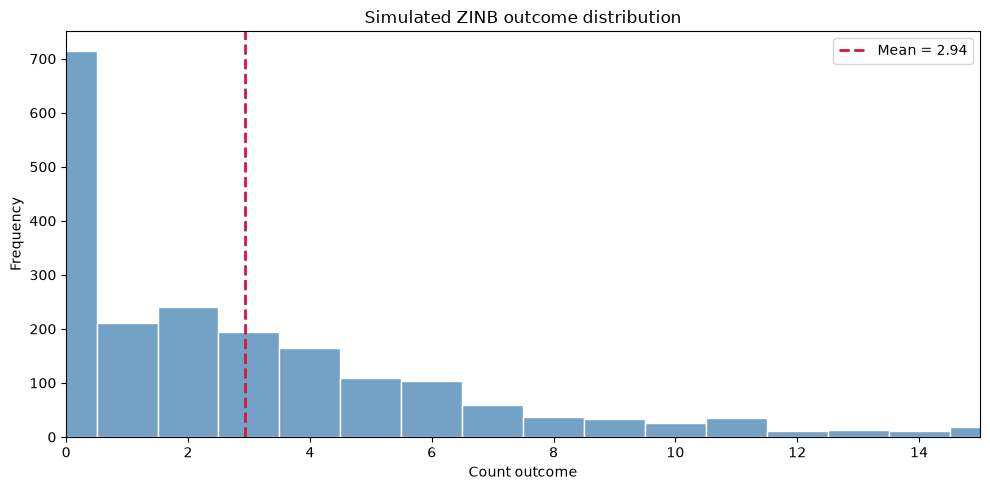

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["y"], discrete=True, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Simulated ZINB outcome distribution")
ax.set_xlabel("Count outcome")
ax.set_ylabel("Frequency")
ax.set_xlim(0, np.quantile(df["y"], 0.99))
ax.axvline(df["y"].mean(), color="crimson", linestyle="--", linewidth=2, label=f"Mean = {df['y'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

## Set up PCNtoolkit

In [4]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    NormalLikelihood,
    ZeroInflatedNegativeBinomialLikelihood,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Build and visualise NormData

      age sex    site     age_z        mu       psi  alpha  y
0     110   F  site13 -1.382274  2.747225  0.764310    2.5  0
1     127   F  site17  0.966535  6.591107  0.700000    2.5  4
2     124   F  site13  0.552039  5.406494  0.700000    2.5  0
3     118   F  site12 -0.276952  3.991600  0.722198    2.5  2
4     118   M   site9 -0.276952  2.987410  0.741809    2.5  4
...   ...  ..     ...       ...       ...       ...    ... ..
1995  108   F   site9 -1.658604  2.365120  0.774120    2.5  1
1996  121   M  site15  0.137543  3.739870  0.725616    2.5  0
1997  132   F   site7  1.657361  7.351415  0.700000    2.5  0
1998  115   M   site2 -0.691448  2.354906  0.757365    2.5  5
1999  115   F   site3 -0.691448  3.064127  0.738520    2.5  0

[2000 rows x 8 columns]


/home/runner/work/PCNtoolkit/PCNtoolkit/pcntoolkit/dataio/norm_data.py:427: UserWarning: No grouping was set for outlier removal, so thresholds are computed across all rows and site differences are ignored. Consider remove_outliers_group_by=['site'] (if available) or your site column.
  dataframe = cls.remove_outliers(


<xarray.DataArray 'batch_effects' (observations: 1999, batch_effect_dims: 2)> Size: 96kB
array([['F', 'site13'],
       ['F', 'site17'],
       ['F', 'site13'],
       ...,
       ['F', 'site7'],
       ['M', 'site2'],
       ['F', 'site3']], shape=(1999, 2), dtype='<U6')
Coordinates:
  * observations       (observations) int64 16kB 0 1 2 3 ... 1995 1996 1997 1998
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'


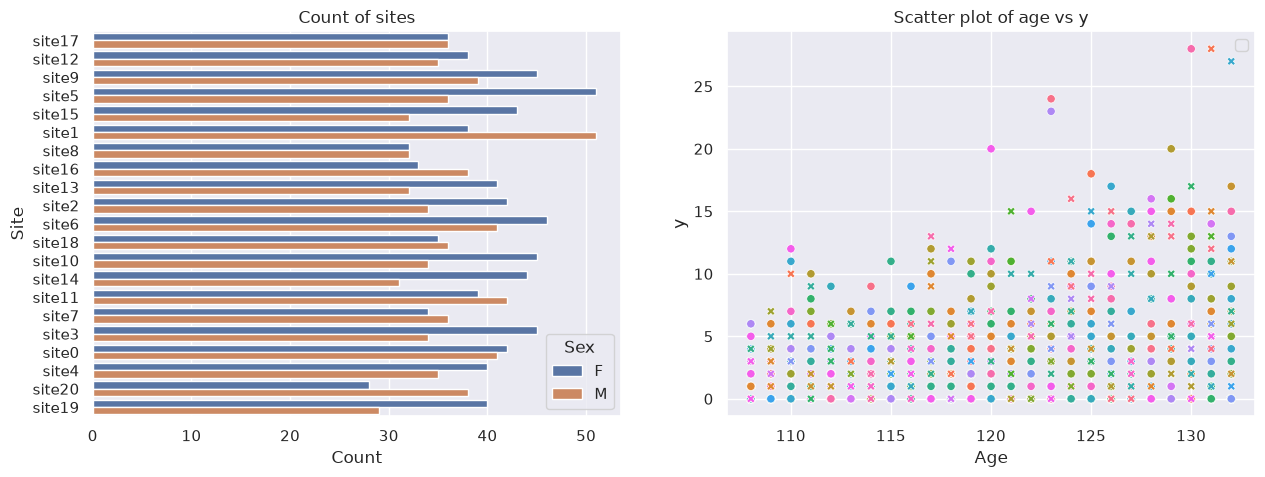

In [5]:
from sklearn.model_selection import train_test_split
from pcntoolkit import NormData

covariate_cols = ["age"]
batch_effects = ["sex", "site"]
response_variables = ["y"]

# Make sure categories / numeric types are sensible
df = df.copy()
df["age"] = df["age"].astype(int)
df["sex"] = df["sex"].astype(str)
df["site"] = df["site"].astype(str)
df["y"] = df["y"].astype(int)

print(df)

# Build NormData
norm_data = NormData.from_dataframe(
    name="ZINB_CBCL_sim",
    dataframe=df,
    covariates=covariate_cols,
    batch_effects=batch_effects,
    response_vars=response_variables,
    remove_outliers=True,
    z_threshold=10,
)

# Split into train and test
train, test = norm_data.train_test_split()

# Visualize the train data
features_to_model = response_variables
feature_to_plot = features_to_model[0]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(
    data=df,
    y=("batch_effects", "site"),
    hue=("batch_effects", "sex"),
    ax=ax[0],
    orient="h",
)
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Count")
ax[0].set_ylabel("Site")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

print(norm_data.batch_effects)


## HBR with ZINB likelihood


In our HBR configuration below we dont use B-splines.
The reason for that is that the simulated data we created earlier are monotonic with age (`eta_mu = 1.2 + 0.35 * age_z + ...`), so just a linear predictor plus the softplus mapping in the HBR modelled `mu` is flexible enough.

In [6]:
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 5.0)),
    intercept=make_prior(
        random=True, # random effects on the intercept for site and sex
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(1.0, 1.0)),
    ),
    mapping="softplus",          # mu must be positive
)

alpha = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    mapping="softplus",          # alpha must be positive
    mapping_params=(0.0, 2.0),
)

psi = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0, 1)),
    intercept=make_prior(dist_name="Normal", dist_params=(0, 1)),
    mapping="sigmoid",           # psi is a probability, must be in (0, 1)
)

likelihood = ZeroInflatedNegativeBinomialLikelihood(mu, alpha, psi)

template_hbr = HBR(
    name="template", 
    cores=4, 
    progressbar=True,
    draws=1500, 
    tune=500, 
    chains=4,
    nuts_sampler="nutpie", 
    likelihood=likelihood,
)


In [7]:
model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=False,
    evaluate_model=False,
    saveresults=False,
    saveplots=False,
    # inscaler scales X (age), not Y. Age is a continuous covariate, so standardizing it is harmless 
    inscaler="standardize",
    # outscaler scales Y. We must not apply the scaling here as 
    # ZINB models counts, so Y must be non-negative and integer.
    outscaler="none",
)

model.fit_predict(train, test)

Output()

<xarray.NormData> Size: 61kB
Dimensions:            (observations: 400, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, centile: 5)
Coordinates:
  * observations       (observations) int64 3kB 1176 1275 1689 ... 745 690 95
  * response_vars      (response_vars) <U1 4B 'y'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) int64 3kB 1176 1275 1689 ... 745 690 95
    Y                  (observations, response_vars) float64 3kB 1.0 5.0 ... 3.0
    X                  (observations, covariates) float64 3kB 115.0 ... 115.0
    batch_effects      (observations, batch_effect_dims) <U6 19kB 'F' ... 'si...
    Z                  (observations, response_vars) float64 3kB -0.2274 ... ...
    centiles           (centile, observations, response_vars) float64 16kB 0....
    baseline_logp      (observations, response_vars) float64 3kB -2.404 ... -...
    logp               (observations, response_vars) float64 3kB -2.087 ... -...
    Yhat               (observations, response_vars) float64 3kB 2.536 ... 2.585
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           ZINB_CBCL_sim_test
    unique_batch_effects:           {np.str_('sex'): ['F', 'M'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 108.0, 'max': 13...
    batch_effect_covariate_ranges:  {np.str_('sex'): {'F': {np.str_('age'): {...

To model a discrete likelihood like ZINB we use a method called randomized quantile residuals. This is what makes discrete y map to a continuous, normally distributed z. This has the cost of making the z-scores **stochastic**. So evaluation metrics computed from z-scores give a different number every time you run the code. These are `ShapiroW`, `Skew` and `Kurtosis`.

`MSLL` is also not meaningful for ZINB, as it compares ZINB (distrete) to a baseline Gaussian which is continuous.

Importantly, the centiles curves and everything else on the y-space remain **deterministic**.

## Plot centiles

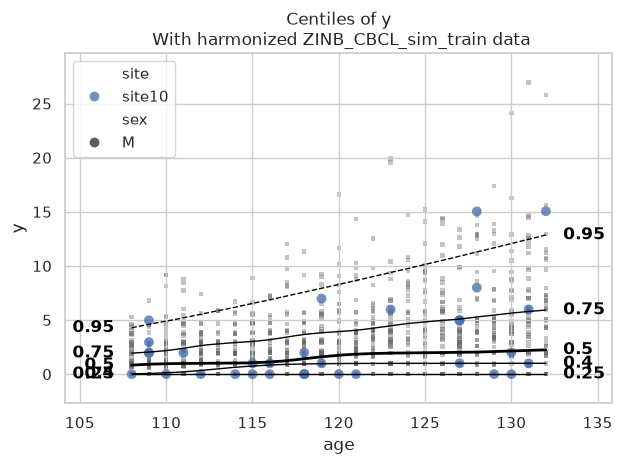

[<Figure size 640x480 with 1 Axes>]

In [8]:
plot_centiles_advanced(
    model,
    centiles=[0.25, 0.4, 0.5, 0.75, 0.95],  # the default centiles are[0.05, 0.25, 0.5, 0.75, 0.95]
    scatter_data=train,  
    batch_effects={"site": ["site10"], "sex": ["M"]},
    show_other_data=True,
    harmonize_data=True, 
)

As we saw earlier 35.75% (`zero_rate = 0.3575`) of the outcomes are zero, so every centile below 0.3575 is expected to mostly be flat on the zero line. That is why the 0.25 centile is a straight line at 0, while the 0.4 centile starts to lift off 0.